In [4]:
pip install kagglehub


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: /Users/omarawilhassan/Desktop/fake news detection/venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd 
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

/Users/omarawilhassan/Desktop/fake news detection/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/omarawilhassan/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [6]:
import pandas as pd

file_path = path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
## fixinf the TotalCharges to float data type
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [10]:
## cheking missing values 
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
## drop missing values since its its not even 1% of our data 
df = df.dropna()

In [12]:
## confirming the missing values 
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## EDA

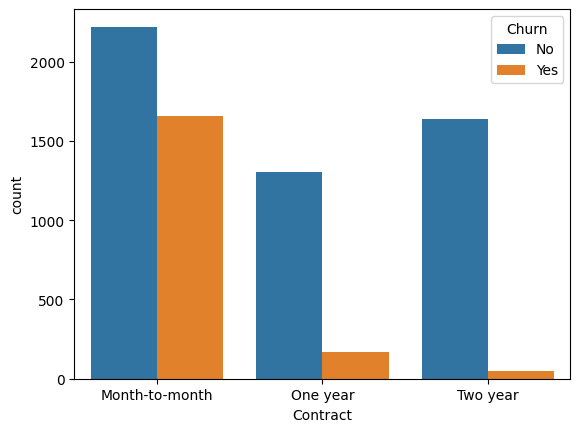

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="Contract", hue="Churn", data=df)
plt.show()

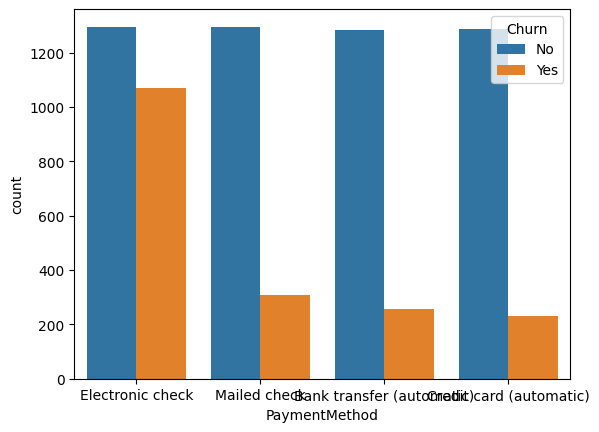

In [14]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.show()

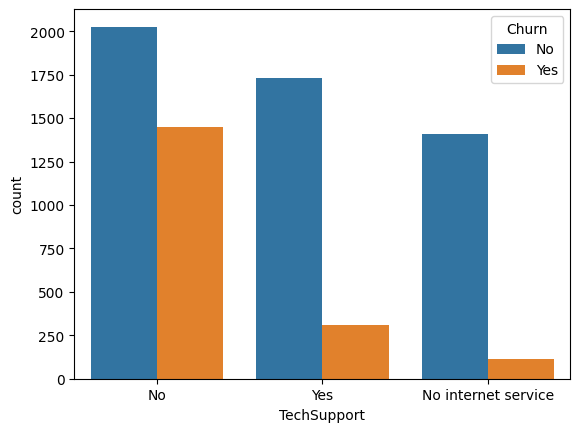

In [15]:
sns.countplot(x="TechSupport", hue="Churn", data=df)
plt.show()

## MACHINE LEARNING (Churn Prediction Model)

## incode 

In [23]:
df = pd.read_csv(file_path)

In [24]:
df = df.drop("customerID", axis=1)

In [25]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

In [26]:
df = pd.get_dummies(df, drop_first=True)

## MODEL IMPROVEMENT (Fixing Class Imbalance)

In [30]:
pip install imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: /Users/omarawilhassan/Desktop/fake news detection/venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
# SMOTE is used to balance imbalanced datasets by creating synthetic samples
# It increases minority class (churn customers) so the model learns better

from imblearn.over_sampling import SMOTE

In [32]:
# X = input features (customer behavior, services, billing info)
# y = target variable (whether customer churned or not)

X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

In [33]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
# We only apply SMOTE on training data (VERY IMPORTANT to avoid data leakage)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
# SMOTE creates synthetic examples of churn customers (minority class)
# This helps the model learn churn patterns better

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [35]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest is retrained on balanced data
# This helps it pay equal attention to churn and non-churn customers

model = RandomForestClassifier(random_state=42)

model.fit(X_train_resampled, y_train_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
# Predict churn on unseen test data
y_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import classification_report

# This report tells us:
# - Precision (correctness of predictions)
# - Recall (how many churners we captured)
# - F1-score (balance)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.86      0.85      0.85      1033
        True       0.59      0.60      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.73      1407
weighted avg       0.79      0.78      0.78      1407



## WHY customers churn

In [38]:
# Feature importance shows which variables the model used most to make decisions
# Higher value = more influence on churn prediction

import pandas as pd

importances = model.feature_importances_

# Create a dataframe for better interpretation
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.164196
1,tenure,0.158088
2,MonthlyCharges,0.132613
28,PaymentMethod_Electronic check,0.102280
10,InternetService_Fiber optic,0.053155
25,Contract_Two year,0.037756
26,PaperlessBilling_Yes,0.037444
9,MultipleLines_Yes,0.024109
4,gender_Male,0.023250
24,Contract_One year,0.021479


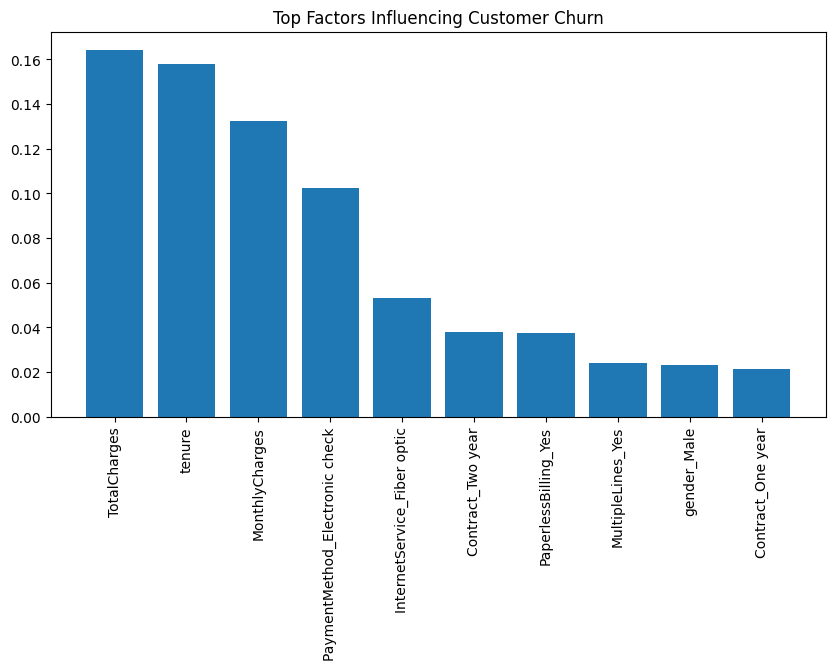

In [39]:
import matplotlib.pyplot as plt

# Take top 10 most important features
top_features = feature_importance.head(10)

plt.figure(figsize=(10,5))
plt.bar(top_features["Feature"], top_features["Importance"])
plt.xticks(rotation=90)
plt.title("Top Factors Influencing Customer Churn")
plt.show()

## STREAMLIT APP (REAL PRODUCT DEMO)

In [40]:
pip install streamlit


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: /Users/omarawilhassan/Desktop/fake news detection/venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [41]:
%%writefile app.py

import streamlit as st
import pandas as pd
from joblib import load

model = load("churn_model.pkl")

st.title("📊 Customer Churn Prediction App")

st.write("Enter customer details to predict churn risk")

tenure = st.slider("Tenure (months)", 0, 72)
monthly_charges = st.slider("Monthly Charges", 0, 150)

if st.button("Predict Churn Risk"):
    input_data = [[tenure, monthly_charges]]
    prediction = model.predict(input_data)

    if prediction[0] == 1:
        st.error("🔴 High Risk of Churn")
    else:
        st.success("🟢 Low Risk of Churn")

Overwriting app.py


In [42]:
import joblib

# Save trained model to file
joblib.dump(model, "churn_model.pkl")

['churn_model.pkl']

In [43]:
from joblib import load

# Load trained model
model = load("churn_model.pkl")

In [44]:
joblib.dump(model, "churn_model.pkl")

['churn_model.pkl']